In [1]:

# phase classification problem
# includes neural netowrk definition and training

In [9]:
#data preparation
import pandas as pd

#data import
col=['TM', 'PT', 'H','CO2', 'CO', 'H2', 'N2', 'Ar', 'RS', '2phase']
data = pd.read_csv("Data/GERG2008_1m.csv",
 encoding="utf-8", nrows=1_000_000, usecols=col)

#phase separation
PH=(2*data['2phase']**0).copy()
PH[data.RS==1]=1
PH[data.RS==0]=0
data['PH']=PH
data['TM']=data['TM']+273.15

In [10]:
# phase classification
from sklearn.model_selection import train_test_split
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# features matrix
X = data.drop(columns=['PH','TM', '2phase', 'RS'])
X['P2']=X['PT']**(1/3)

# target vector
y=data['PH'] # separtion of regions: 0 - liquid, 1 - gas, 2 - two phases

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# features normalization
xtm=X_train.mean()
xts=X_train.std()

X_tr=(X_train-xtm)/xts # normalized train data
X_ts=(X_test-xtm)/xts # normalized test data

# train/test data conversion to tensors
XX = torch.tensor(np.array(X_tr), dtype=torch.float32)
yy = torch.tensor(np.array(y_train), dtype=torch.long).reshape(-1, 1)

XX_ts = torch.tensor(np.array(X_ts), dtype=torch.float32)
yy_ts = torch.tensor(np.array(y_test), dtype=torch.long).reshape(-1, 1)

# network architecture 
model = nn.Sequential(
    nn.Linear(len(X.loc[0]), 5),
    nn.Tanh(),
    nn.Linear(5, 5),
    nn.Tanh(),
    nn.Linear(5, 3),
    #nn.Softmax(dim=1))
    nn.Tanh())

# loss function definition
loss_fn=nn.CrossEntropyLoss()

# optimizer 
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
# training 
n_epochs = 300
batch_size = 200

lls=[] #loss function value in each epoch
for epoch in range(n_epochs):
    if epoch>150:
        optimizer = optim.Adam(model.parameters(), lr=0.0005)
    for i in range(0, len(XX), batch_size):
        Xbatch = XX[i:i+batch_size]
        y_logits = model(Xbatch)
        ybatch = yy[i:i+batch_size]
        loss = loss_fn(y_logits, ybatch.squeeze())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Finished epoch {epoch}, latest loss {loss}')
    lls.append(loss.item())

Finished epoch 0, latest loss 0.26093876361846924
Finished epoch 1, latest loss 0.2530200481414795
Finished epoch 2, latest loss 0.2508889138698578
Finished epoch 3, latest loss 0.2501540184020996
Finished epoch 4, latest loss 0.24989642202854156
Finished epoch 5, latest loss 0.249678835272789
Finished epoch 6, latest loss 0.24948346614837646
Finished epoch 7, latest loss 0.24937458336353302
Finished epoch 8, latest loss 0.2493295669555664
Finished epoch 9, latest loss 0.24932575225830078
Finished epoch 10, latest loss 0.24932493269443512
Finished epoch 11, latest loss 0.24928350746631622
Finished epoch 12, latest loss 0.24918001890182495
Finished epoch 13, latest loss 0.24901710450649261
Finished epoch 14, latest loss 0.248803049325943
Finished epoch 15, latest loss 0.248545840382576
Finished epoch 16, latest loss 0.24825039505958557
Finished epoch 17, latest loss 0.247915580868721
Finished epoch 18, latest loss 0.24753470718860626
Finished epoch 19, latest loss 0.2471049726009369
Fin

In [12]:
# prediction and accuracy estimation
with torch.no_grad():
    y_pred_train = (model(XX)).argmax(dim=1).reshape(-1,1)
    y_pred_test = (model(XX_ts)).argmax(dim=1).reshape(-1,1)

print('accuracy train: ',(sum(y_pred_train==yy)/len(yy)).item())
print('accuracy test: ',(sum(y_pred_test==yy_ts)/len(yy_ts)).item())

accuracy train:  0.9977162480354309
accuracy test:  0.9978200197219849


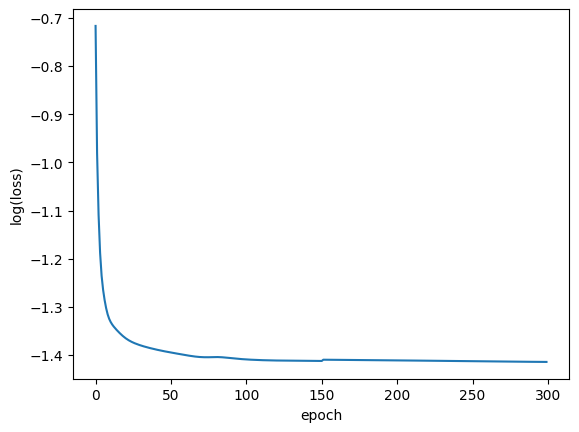

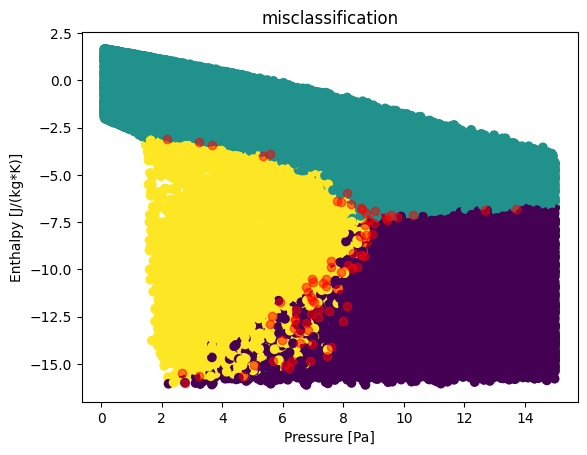

In [7]:
# results visualization
import matplotlib.pyplot as plt

# learning curve
plt.plot(np.log(lls))
plt.xlabel('epoch')
plt.ylabel('log(loss)')
plt.show()

# misclassification (red dots - misclassified points)
plt.figure()
mask=np.array(y_pred_test!=yy_ts)
mask=mask.reshape(len(mask))
plt.scatter(X.PT,X.H,c=y);
plt.scatter(X_test.PT[mask],X_test.H[mask],c='r',alpha=0.5);
plt.title('misclassification')
plt.xlabel('Pressure [Pa]')
plt.ylabel('Enthalpy [J/(kg*K)]')
plt.show();

In [13]:
import pickle
pickle.dump([xtm,xts,model],open('model_classification_PH_T','wb'))